# Iran Partial-Recovery Forecast Model

Exploratory model for the post-shutdown Iran DAU regime that began ~March 2026.
Under Iran's new tiered internet system, the online population is a small, vetted
subset (state employees, registered professionals, business owners). Gray-market
users (Starlink, VPN) appear under *destination* countries, not `country=IR`, so we're
only modeling the Internet Pro + White SIM tiers here.

**Model:** `y(t) = trend(t) × weekly_factor(dow(t))` where `trend` is a 3-parameter
logistic. All three trend parameters (cap, growth rate, inflection) are **fit from
data** — we want to see whether the natural fit lands inside a plausible demographic
range (~50k–200k DAU based on Internet Pro eligibility × privacy-conscious-elevated
Firefox share) before deciding whether to pin the cap.

**Iterative fit:** seasonality is extracted with a centered 7-day rolling-mean detrend
(pass 1), the logistic is fit, then seasonality is re-extracted using the fitted
logistic as the detrend reference (pass 2), and the logistic is refit. This corrects
the bias the rolling-mean detrend introduces during steep growth.

**Fit window:** April 15, 2026 onward. Plots are zoomed to 2026-03-22 → 2026-08-01.

In [21]:
# [setup]
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.cloud import bigquery
from scipy.optimize import curve_fit

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

PLOT_START = pd.Timestamp('2026-03-22')
PLOT_END = pd.Timestamp('2026-08-01')
FIT_START = pd.Timestamp('2026-04-15')
TODAY = pd.Timestamp('2026-05-15')
FORECAST_END = pd.Timestamp('2027-12-31')  # production horizon (forecast computed this far, but plots stop at PLOT_END)

BQ_PROJECT = 'moz-fx-data-bq-data-science'
DOW_LABELS = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

print('Setup complete.')

Setup complete.


In [22]:
# [query]
client = bigquery.Client(project=BQ_PROJECT)

SQL = """
SELECT
  submission_date,
  SUM(dau) AS dau
FROM `moz-fx-data-shared-prod.telemetry.active_users_aggregates`
WHERE submission_date >= DATE(2026, 1, 1)
  AND app_name = 'Firefox Desktop'
  AND channel = 'release'
  AND country = 'IR'
GROUP BY submission_date
ORDER BY submission_date
"""

raw = client.query(SQL).to_dataframe()
raw['submission_date'] = pd.to_datetime(raw['submission_date'])
raw = raw.set_index('submission_date').sort_index()
print(f'Pulled {len(raw)} rows; range {raw.index.min().date()} to {raw.index.max().date()}')
raw.tail()

Pulled 133 rows; range 2026-01-01 to 2026-05-13


,dau
submission_date,
2026-05-09,58678
2026-05-10,61738
2026-05-11,64456
2026-05-12,67351
2026-05-13,64200


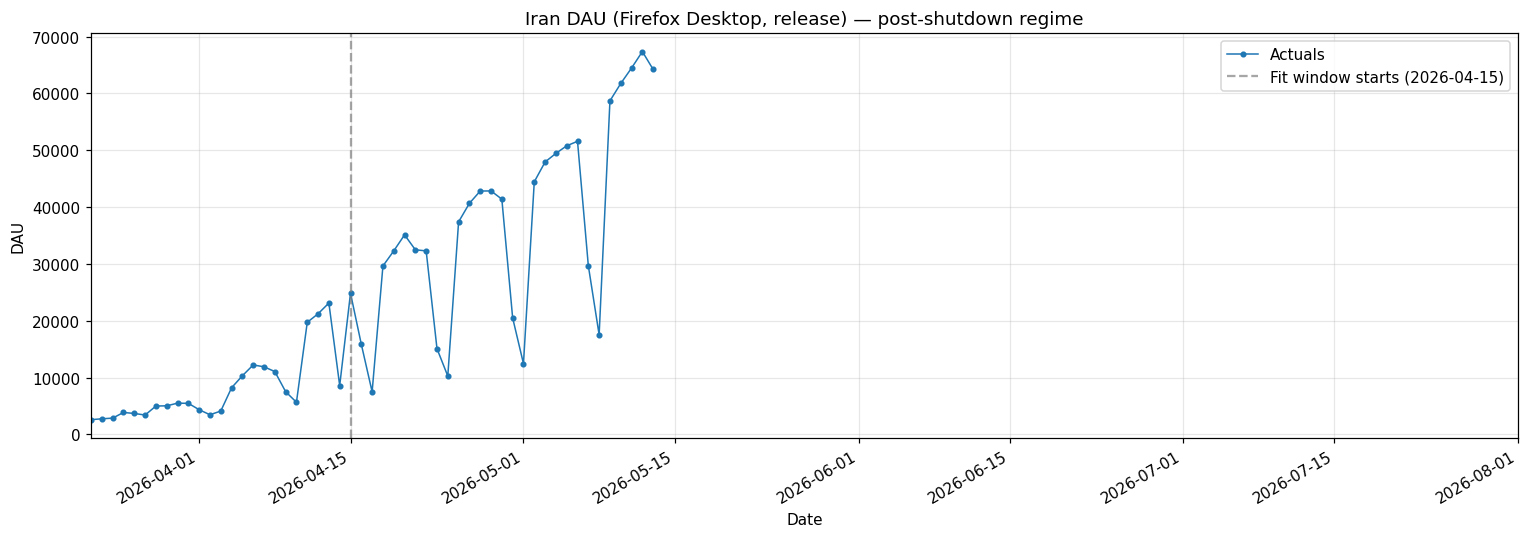

In [23]:
# [raw-plot]
plot_data = raw[(raw.index >= PLOT_START) & (raw.index <= PLOT_END)]

fig, ax = plt.subplots()
ax.plot(plot_data.index, plot_data['dau'], marker='o', markersize=3, linewidth=1, color='C0', label='Actuals')
ax.axvline(FIT_START, color='grey', linestyle='--', alpha=0.7, label=f'Fit window starts ({FIT_START.date()})')
ax.set_title('Iran DAU (Firefox Desktop, release) — post-shutdown regime')
ax.set_ylabel('DAU')
ax.set_xlabel('Date')
ax.set_xlim(PLOT_START, PLOT_END)
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Iterative seasonal + trend fit

The helper below runs the two-pass procedure:

1. **Pass 1.** Detrend with a centered 7-day rolling mean → daily ratios → averaged by
   day-of-week → normalized to geomean=1. Fit logistic on deseasonalized data.
2. **Pass 2.** Use the fitted logistic from pass 1 as the detrend reference. Re-extract
   day-of-week factors. Refit the logistic.

Two iterations is enough in practice — the seasonal factors stabilize quickly once the
trend reference is reasonable. The function returns both passes so we can compare.

In [24]:
# [fit-helper]
def logistic(t, cap, k, t0):
    return cap / (1.0 + np.exp(-k * (t - t0)))

# Cap upper bound = 850k (Iran's pre-shutdown DAU peak, an absolute physical ceiling).
LOGISTIC_P0 = [120_000.0, 0.06, 30.0]
LOGISTIC_BOUNDS = ([10_000.0, 0.001, -200.0], [850_000.0, 2.0, 1000.0])


def _normalized_factors(ratios_by_dow):
    """Reindex to all 7 dows (fill missing with 1.0), then normalize to geomean=1."""
    factors = ratios_by_dow.reindex(range(7), fill_value=1.0)
    return factors / np.exp(np.log(factors).mean())


def fit_iteratively(window_df, start_ts):
    """Two-pass iterative fit. Returns dict with pass1, pass2, and final == pass2."""
    df = window_df.copy()
    df['dow'] = df.index.dayofweek
    df['t_days'] = (df.index - start_ts).days.astype(float)

    # Pass 1: rolling-mean detrend
    df['smooth'] = df['dau'].rolling(7, center=True, min_periods=4).mean()
    df['ratio_v1'] = df['dau'] / df['smooth']
    wf_v1 = _normalized_factors(
        df.dropna(subset=['ratio_v1']).groupby('dow')['ratio_v1'].mean()
    )
    df['dau_des_v1'] = df['dau'] / df['dow'].map(wf_v1)

    params_v1, cov_v1 = curve_fit(
        logistic, df['t_days'].values, df['dau_des_v1'].values,
        p0=LOGISTIC_P0, bounds=LOGISTIC_BOUNDS, maxfev=10_000,
    )

    # Pass 2: use logistic_v1 as detrend reference
    df['trend_v1'] = logistic(df['t_days'].values, *params_v1)
    df['ratio_v2'] = df['dau'] / df['trend_v1']
    wf_v2 = _normalized_factors(df.groupby('dow')['ratio_v2'].mean())
    df['dau_des_v2'] = df['dau'] / df['dow'].map(wf_v2)

    params_v2, cov_v2 = curve_fit(
        logistic, df['t_days'].values, df['dau_des_v2'].values,
        p0=params_v1, bounds=LOGISTIC_BOUNDS, maxfev=10_000,
    )

    return {
        'pass1': {'params': params_v1, 'cov': cov_v1, 'weekly_factor': wf_v1},
        'pass2': {'params': params_v2, 'cov': cov_v2, 'weekly_factor': wf_v2},
        'final': {'params': params_v2, 'cov': cov_v2, 'weekly_factor': wf_v2},
    }

print('Helper defined.')


Helper defined.


In [25]:
# [run-fit]
result = fit_iteratively(raw[raw.index >= FIT_START], FIT_START)

params_final = result['final']['params']
perr_final = np.sqrt(np.diag(result['final']['cov']))
weekly_factor_final = result['final']['weekly_factor']
cap_final, k_final, t0_final = params_final

p1, p2 = result['pass1']['params'], result['pass2']['params']
wf1, wf2 = result['pass1']['weekly_factor'], result['pass2']['weekly_factor']

print('Pass 1 -> Pass 2 (after seasonality refit):')
print(f'  cap:        {p1[0]:>12,.0f} -> {p2[0]:>12,.0f}   (delta {(p2[0]-p1[0])/p1[0]*100:+.1f}%)')
print(f'  k:          {p1[1]:>12.4f} -> {p2[1]:>12.4f}   (delta {(p2[1]-p1[1])/p1[1]*100:+.1f}%)')
print(f'  t0 (days):  {p1[2]:>12.1f} -> {p2[2]:>12.1f}   (delta {p2[2]-p1[2]:+.1f}d)')
print()
print('Weekly factors pass 1 -> pass 2:')
for i, lbl in enumerate(DOW_LABELS):
    print(f'  {lbl}:  {wf1[i]:.3f} -> {wf2[i]:.3f}')
print()
print('=' * 60)
print('Final parameters:')
print(f'  cap         = {cap_final:>10,.0f}   (1-sigma +/- {perr_final[0]:,.0f})')
print(f'  k           = {k_final:>10.4f}   (1-sigma +/- {perr_final[1]:.4f})')
print(f'  inflection  = {(FIT_START + pd.Timedelta(days=t0_final)).date()}   (1-sigma +/- {perr_final[2]:.1f}d)')
print(f'  doubling time near inflection: {np.log(2) / k_final:.1f} days')
print(f'  trend at last actual ({raw.index.max().date()}): {logistic((raw.index.max() - FIT_START).days, *params_final):,.0f}  (observed: {raw["dau"].iloc[-1]:,.0f})')

Pass 1 -> Pass 2 (after seasonality refit):
  cap:             850,000 ->      850,000   (delta -0.0%)
  k:                0.0348 ->       0.0347   (delta -0.4%)
  t0 (days):         106.8 ->        107.3   (delta +0.4d)

Weekly factors pass 1 -> pass 2:
  Mon:  1.369 -> 1.380
  Tue:  1.311 -> 1.332
  Wed:  1.277 -> 1.258
  Thu:  0.677 -> 0.662
  Fri:  0.373 -> 0.371
  Sat:  1.291 -> 1.299
  Sun:  1.337 -> 1.353

Final parameters:
  cap         =    850,000   (1-sigma +/- 5,488,959)
  k           =     0.0347   (1-sigma +/- 0.0097)
  inflection  = 2026-07-31   (1-sigma +/- 219.9d)
  doubling time near inflection: 20.0 days
  trend at last actual (2026-05-13): 51,212  (observed: 64,200)


## Final forecast — static plot

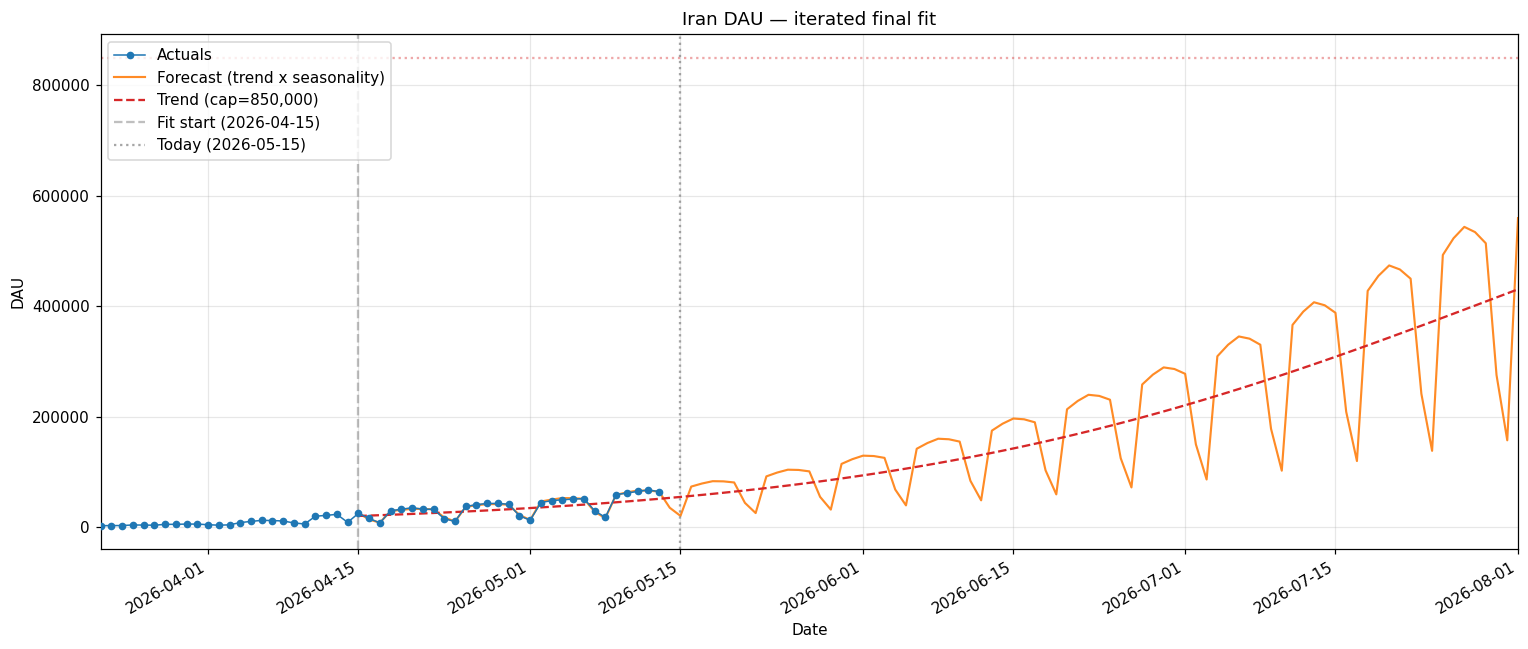

In [26]:
# [forecast-plot]
future_dates = pd.date_range(start=FIT_START, end=FORECAST_END, freq='D')
t_future = (future_dates - FIT_START).days.astype(float)
trend_future = logistic(t_future, *params_final)
seasonal_future = np.array([weekly_factor_final[d] for d in future_dates.dayofweek])
forecast = trend_future * seasonal_future

forecast_df = pd.DataFrame(
    {'trend': trend_future, 'seasonal': seasonal_future, 'forecast': forecast},
    index=future_dates,
)

plot_actuals = raw[(raw.index >= PLOT_START) & (raw.index <= PLOT_END)]
plot_forecast = forecast_df[(forecast_df.index >= PLOT_START) & (forecast_df.index <= PLOT_END)]

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(plot_actuals.index, plot_actuals['dau'], marker='o', markersize=4, linewidth=1, color='C0', label='Actuals', zorder=3)
ax.plot(plot_forecast.index, plot_forecast['forecast'], linewidth=1.4, color='C1', label='Forecast (trend x seasonality)', alpha=0.9)
ax.plot(plot_forecast.index, plot_forecast['trend'], linewidth=1.5, color='C3', linestyle='--', label=f'Trend (cap={cap_final:,.0f})')
ax.axhline(cap_final, color='C3', linestyle=':', alpha=0.4)
ax.axvline(FIT_START, color='grey', linestyle='--', alpha=0.5, label=f'Fit start ({FIT_START.date()})')
ax.axvline(TODAY, color='grey', linestyle=':', alpha=0.7, label=f'Today ({TODAY.date()})')
ax.set_title('Iran DAU — iterated final fit')
ax.set_ylabel('DAU')
ax.set_xlabel('Date')
ax.set_xlim(PLOT_START, PLOT_END)
ax.legend(loc='upper left')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Final forecast — interactive plot

Zoomable / pannable plotly version. Hover for daily values.

In [27]:
# [interactive-plot]
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=plot_actuals.index, y=plot_actuals['dau'],
    mode='markers+lines', marker=dict(size=5), name='Actuals',
    line=dict(color='royalblue', width=1.2),
))
fig.add_trace(go.Scatter(
    x=plot_forecast.index, y=plot_forecast['forecast'],
    mode='lines', name='Forecast',
    line=dict(color='darkorange', width=1.6),
))
fig.add_trace(go.Scatter(
    x=plot_forecast.index, y=plot_forecast['trend'],
    mode='lines', name='Trend',
    line=dict(color='firebrick', width=1.5, dash='dash'),
))
fig.add_hline(
    y=cap_final, line=dict(color='firebrick', dash='dot'),
    annotation_text=f'cap = {cap_final:,.0f}',
    annotation_position='top right',
)
# add_vline's annotation path does arithmetic on x-values, which fails for
# both Timestamps and strings in plotly 6.x. Use add_shape + add_annotation directly.
_today_iso = TODAY.strftime('%Y-%m-%d')
fig.add_shape(
    type='line', x0=_today_iso, x1=_today_iso, y0=0, y1=1, yref='paper',
    line=dict(color='grey', dash='dot'),
)
fig.add_annotation(
    x=_today_iso, y=1.02, yref='paper', text='Today',
    showarrow=False, font=dict(color='grey'),
)
fig.update_layout(
    title=f'Iran DAU forecast — interactive (cap={cap_final:,.0f})',
    xaxis_title='Date',
    yaxis_title='DAU',
    hovermode='x unified',
    width=1100, height=600,
    xaxis=dict(range=[PLOT_START.strftime('%Y-%m-%d'), PLOT_END.strftime('%Y-%m-%d')]),
)
fig.show()


## Text summary (paste back to iterate)

Compact text summary suitable for pasting into chat so we can iterate on the result.

In [28]:
# [text-summary]
combined = forecast_df[['forecast', 'trend']].copy()
combined['actual'] = raw['dau']
combined = combined[combined.index <= PLOT_END]
combined['week_start'] = combined.index - pd.to_timedelta(combined.index.dayofweek, unit='d')

weekly = combined.groupby('week_start').agg(
    actual=('actual', 'mean'),
    forecast=('forecast', 'mean'),
    trend=('trend', 'mean'),
).round(0)
weekly = weekly[weekly.index >= (PLOT_START - pd.Timedelta(days=7))]

BAR_WIDTH = 32
lines = []
lines.append('=' * 78)
lines.append('Iran Partial-Recovery Forecast (iterated fit)')
lines.append('=' * 78)
lines.append(f'Fit window: {FIT_START.date()} -> {raw.index.max().date()} ({(raw.index.max() - FIT_START).days + 1} days)')
lines.append(f'Plot window: {PLOT_START.date()} -> {PLOT_END.date()}')
lines.append('')
lines.append('Final parameters:')
lines.append(f'  cap         = {cap_final:>10,.0f}   (1-sigma +/- {perr_final[0]:,.0f})')
lines.append(f'  k           = {k_final:>10.4f}   (doubling ~{np.log(2)/k_final:.1f}d, 1-sigma +/- {perr_final[1]:.4f})')
lines.append(f'  inflection  = {(FIT_START + pd.Timedelta(days=t0_final)).date()}   (1-sigma +/- {perr_final[2]:.1f}d)')
lines.append('')
lines.append('Weekly seasonality factors (geomean=1):')
lines.append('  ' + '   '.join(f'{lbl}={weekly_factor_final[i]:.2f}' for i, lbl in enumerate(DOW_LABELS)))
lines.append('')
lines.append('Pass 1 -> Pass 2 cap shift:  '
             f"{p1[0]:,.0f} -> {p2[0]:,.0f}  ({(p2[0]-p1[0])/p1[0]*100:+.1f}%)")
lines.append('')
lines.append(f'Weekly trajectory (bar width = pct of cap; full bar = cap {cap_final:,.0f})')
lines.append(f"  {'week-start':<12}  {'actual':>9}  {'forecast':>9}  {'pct-cap':>8}  bar")
lines.append(f"  {'-'*12}  {'-'*9}  {'-'*9}  {'-'*8}  {'-'*BAR_WIDTH}")
for ws, row in weekly.iterrows():
    val = row['actual'] if not pd.isna(row['actual']) else row['forecast']
    bar_n = max(0, min(BAR_WIDTH, int(round(BAR_WIDTH * val / cap_final))))
    bar = '#' * bar_n + '.' * (BAR_WIDTH - bar_n)
    actual_str = f"{row['actual']:,.0f}" if not pd.isna(row['actual']) else '-'
    fc_str = f"{row['forecast']:,.0f}" if not pd.isna(row['forecast']) else '-'
    marker = '(a)' if not pd.isna(row['actual']) else '(f)'
    lines.append(f'  {ws.strftime("%Y-%m-%d"):<12}  {actual_str:>9}  {fc_str:>9}  {100*val/cap_final:>7.1f}%  {bar} {marker}')
lines.append('')
lines.append('Legend: (a) week has actuals (may be partial for current week); (f) forecast only')

print('\n'.join(lines))

Iran Partial-Recovery Forecast (iterated fit)
Fit window: 2026-04-15 -> 2026-05-13 (29 days)
Plot window: 2026-03-22 -> 2026-08-01

Final parameters:
  cap         =    850,000   (1-sigma +/- 5,488,959)
  k           =     0.0347   (doubling ~20.0d, 1-sigma +/- 0.0097)
  inflection  = 2026-07-31   (1-sigma +/- 219.9d)

Weekly seasonality factors (geomean=1):
  Mon=1.38   Tue=1.33   Wed=1.26   Thu=0.66   Fri=0.37   Sat=1.30   Sun=1.35

Pass 1 -> Pass 2 cap shift:  850,000 -> 850,000  (-0.0%)

Weekly trajectory (bar width = pct of cap; full bar = cap 850,000)
  week-start       actual   forecast   pct-cap  bar
  ------------  ---------  ---------  --------  --------------------------------
  2026-04-13       22,017     21,478      2.6%  #............................... (a)
  2026-04-20       29,035     28,819      3.4%  #............................... (a)
  2026-04-27       36,047     36,421      4.2%  #............................... (a)
  2026-05-04       45,627     45,926      5.4%  

## Phase-space sweep: daily refits

With cap now bounded at 850k (Iran's pre-shutdown DAU peak — an absolute physical
ceiling), we sweep fit-start dates daily from Mar 22 through May 1 to map the
parameter phase space. The goal is to find the "consensus" fit: most start dates
should converge to similar values, and any outliers reveal which slices of data
leave the cap unidentified.

The first figure shows each fitted parameter as a function of fit-start date (with
1-sigma bands). The second overlays all forecast curves, colored by fit-start.
Fits that hit the upper bound on cap are flagged in red.


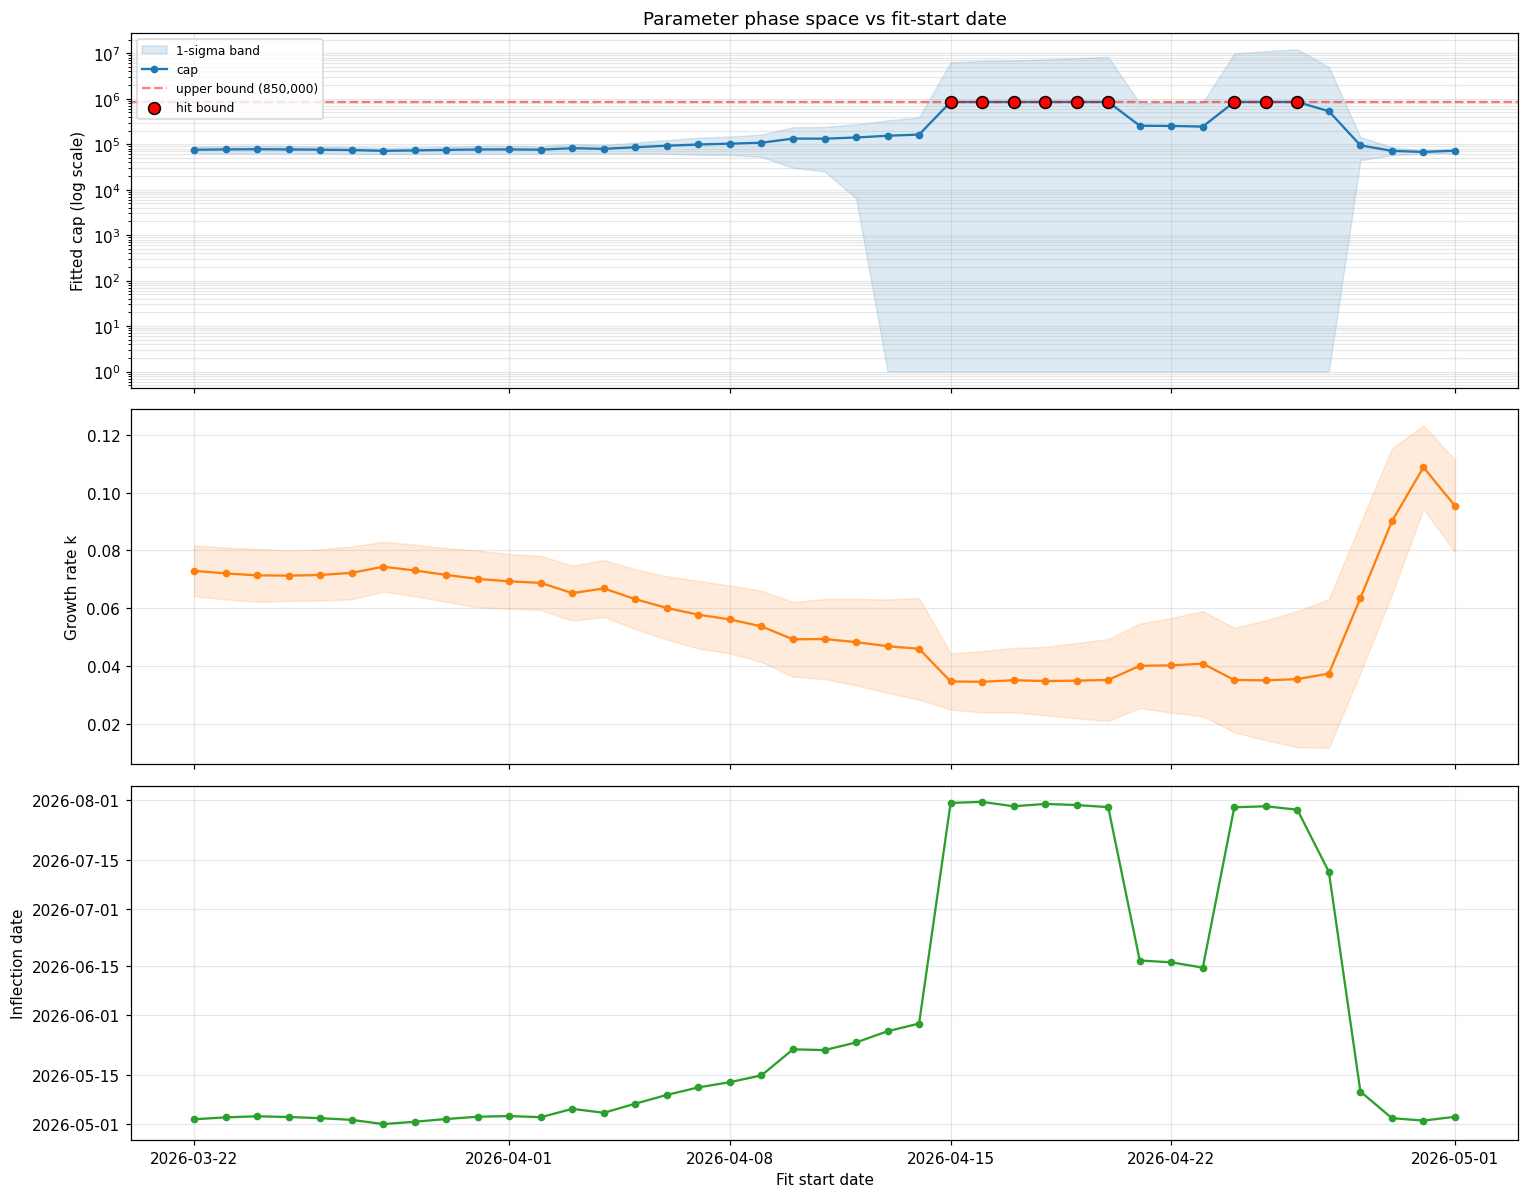

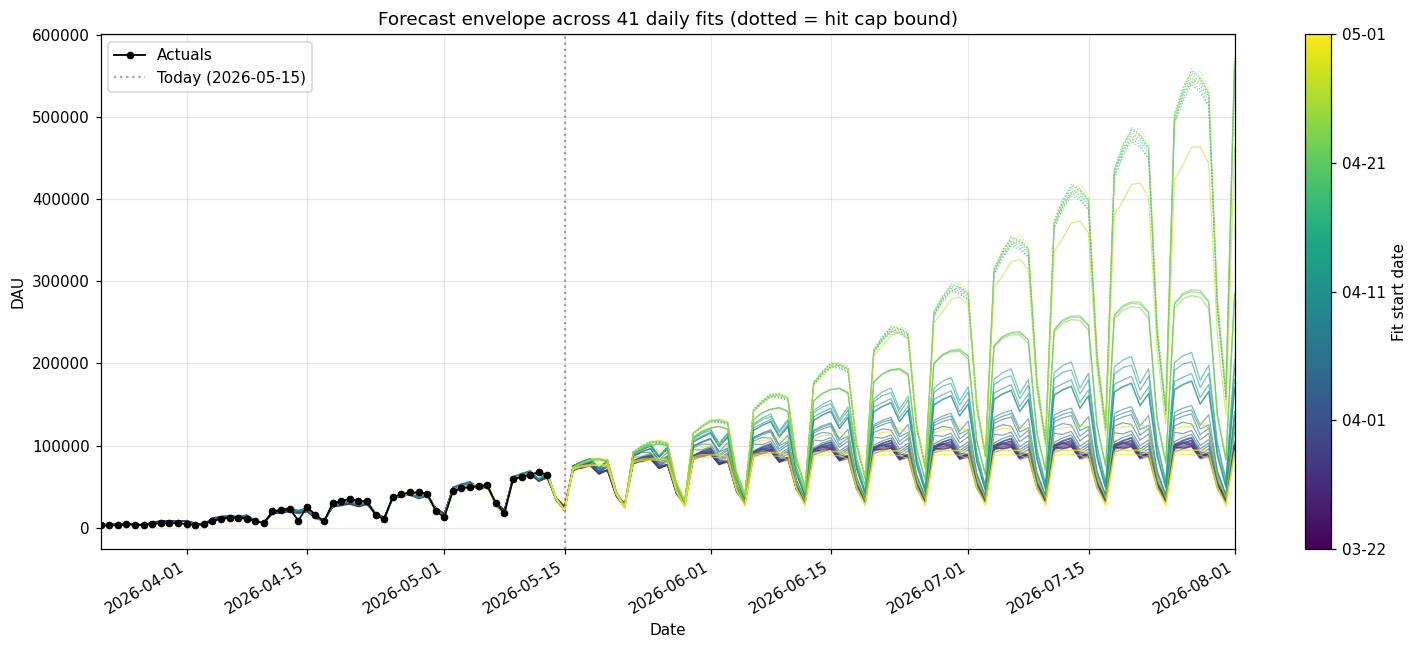

Successful fits:        41/41
Hit upper bound (850k): 9
Unbounded (usable):     32

Cap statistics (unbounded fits only):
  median:     80,441
  mean:      120,824
  range:      67,557  -  532,029
  IQR:        75,699  -  132,554

Growth rate k statistics (unbounded fits only):
  median: 0.0660
  IQR:    0.0493  -  0.0716


,n_days_obs,cap,cap_sigma,k,inflection_date,at_cap_bound
fit_start,,,,,,
2026-03-22,53,75446.899075,1.291367e+04,0.072941,2026-05-02 09:34:13.510762139,False
2026-03-23,52,76811.579050,1.394477e+04,0.072020,2026-05-02 22:19:17.394203701,False
2026-03-24,51,77566.270796,1.476830e+04,0.071361,2026-05-03 05:49:44.941854003,False
2026-03-25,50,76820.967763,1.376350e+04,0.071264,2026-05-03 00:51:20.152590620,False
2026-03-26,49,75850.104014,1.334296e+04,0.071478,2026-05-02 17:00:53.571395701,False
2026-03-27,48,74562.248187,1.293730e+04,0.072236,2026-05-02 05:20:28.648570947,False
2026-03-28,47,71377.014960,1.047505e+04,0.074336,2026-05-01 00:39:29.603307151,False
2026-03-29,46,73020.531576,1.168933e+04,0.073054,2026-05-01 16:25:22.128270316,False
2026-03-30,45,74991.166031,1.331392e+04,0.071501,2026-05-02 11:19:51.945934906,False


In [29]:
# [phase-space-sweep]
import matplotlib.dates as mdates
from matplotlib import cm

# Daily sweep from Mar 22 to May 1 (inclusive)
candidate_starts = pd.date_range('2026-03-22', '2026-05-01', freq='D')

rows = []
forecasts_by_start = {}
CAP_UPPER = LOGISTIC_BOUNDS[1][0]

for start in candidate_starts:
    window = raw[raw.index >= start]
    n_days_obs = (raw.index.max() - start).days + 1
    try:
        res = fit_iteratively(window, start)
        p = res['final']['params']
        wf = res['final']['weekly_factor']
        perr_i = np.sqrt(np.diag(res['final']['cov']))

        future_i = pd.date_range(start=start, end=FORECAST_END, freq='D')
        t_fi = (future_i - start).days.astype(float)
        trend_i = logistic(t_fi, *p)
        seasonal_i = np.array([wf[d] for d in future_i.dayofweek])
        fc_i = pd.Series(trend_i * seasonal_i, index=future_i)
        forecasts_by_start[start] = fc_i

        rows.append({
            'fit_start': start,
            'n_days_obs': n_days_obs,
            'cap': p[0],
            'cap_sigma': perr_i[0],
            'k': p[1],
            'k_sigma': perr_i[1],
            'inflection_date': start + pd.Timedelta(days=p[2]),
            't0_sigma_days': perr_i[2],
            'at_cap_bound': p[0] >= 0.99 * CAP_UPPER,
        })
    except (RuntimeError, ValueError) as e:
        rows.append({
            'fit_start': start, 'n_days_obs': n_days_obs,
            'cap': np.nan, 'cap_sigma': np.nan,
            'k': np.nan, 'k_sigma': np.nan,
            'inflection_date': pd.NaT, 't0_sigma_days': np.nan,
            'at_cap_bound': False,
        })
        print(f'Fit failed for start={start.date()}: {e}')

sweep = pd.DataFrame(rows).set_index('fit_start')

# ---- Parameter trajectory plots ----
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

ax = axes[0]
ax.fill_between(
    sweep.index,
    np.maximum(sweep['cap'] - sweep['cap_sigma'], 1),
    sweep['cap'] + sweep['cap_sigma'],
    alpha=0.15, color='C0', label='1-sigma band',
)
ax.plot(sweep.index, sweep['cap'], 'o-', color='C0', markersize=4, label='cap')
ax.axhline(CAP_UPPER, color='red', linestyle='--', alpha=0.5, label=f'upper bound ({CAP_UPPER:,.0f})')
bound_mask = sweep['at_cap_bound']
if bound_mask.any():
    ax.scatter(sweep.index[bound_mask], sweep.loc[bound_mask, 'cap'],
               color='red', s=60, zorder=5, label='hit bound', edgecolors='black')
ax.set_yscale('log')
ax.set_ylabel('Fitted cap (log scale)')
ax.set_title('Parameter phase space vs fit-start date')
ax.legend(fontsize=8, loc='upper left')
ax.grid(alpha=0.3, which='both')

ax = axes[1]
ax.fill_between(
    sweep.index, sweep['k'] - sweep['k_sigma'], sweep['k'] + sweep['k_sigma'],
    alpha=0.15, color='C1',
)
ax.plot(sweep.index, sweep['k'], 'o-', color='C1', markersize=4)
ax.set_ylabel('Growth rate k')
ax.grid(alpha=0.3)

ax = axes[2]
ax.plot(sweep.index, sweep['inflection_date'], 'o-', color='C2', markersize=4)
ax.set_ylabel('Inflection date')
ax.set_xlabel('Fit start date')
ax.yaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ---- Forecast envelope: all curves colored by fit-start ----
fig, ax = plt.subplots(figsize=(14, 6))
plot_actuals_sw = raw[(raw.index >= PLOT_START) & (raw.index <= PLOT_END)]
ax.plot(plot_actuals_sw.index, plot_actuals_sw['dau'],
        'o-', markersize=4, color='black', label='Actuals', zorder=5, linewidth=1.2)

starts_list = sorted(forecasts_by_start.keys())
n_starts = len(starts_list)
cmap = cm.viridis

for i, start in enumerate(starts_list):
    fc = forecasts_by_start[start]
    color = cmap(i / max(1, n_starts - 1))
    is_bound = sweep.loc[start, 'at_cap_bound']
    linestyle = ':' if is_bound else '-'
    mask = (fc.index >= PLOT_START) & (fc.index <= PLOT_END)
    ax.plot(fc.index[mask], fc[mask], color=color, linewidth=0.8, alpha=0.6, linestyle=linestyle)

norm = plt.Normalize(vmin=0, vmax=max(1, n_starts - 1))
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
n_ticks = 5
tick_idx = np.linspace(0, n_starts - 1, n_ticks).astype(int)
cbar = fig.colorbar(sm, ax=ax, ticks=tick_idx)
cbar.ax.set_yticklabels([starts_list[i].strftime('%m-%d') for i in tick_idx])
cbar.set_label('Fit start date')

ax.axvline(TODAY, color='grey', linestyle=':', alpha=0.7, label=f'Today ({TODAY.date()})')
ax.set_title(f'Forecast envelope across {n_starts} daily fits (dotted = hit cap bound)')
ax.set_ylabel('DAU')
ax.set_xlabel('Date')
ax.set_xlim(PLOT_START, PLOT_END)
ax.legend(loc='upper left')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# ---- Summary statistics ----
valid = sweep.dropna(subset=['cap'])
unbounded = valid[~valid['at_cap_bound']]

print(f'Successful fits:        {len(valid)}/{len(sweep)}')
print(f'Hit upper bound (850k): {valid["at_cap_bound"].sum()}')
print(f'Unbounded (usable):     {len(unbounded)}')
print()
if len(unbounded) > 0:
    print('Cap statistics (unbounded fits only):')
    print(f'  median: {unbounded["cap"].median():>10,.0f}')
    print(f'  mean:   {unbounded["cap"].mean():>10,.0f}')
    print(f'  range:  {unbounded["cap"].min():>10,.0f}  -  {unbounded["cap"].max():,.0f}')
    print(f'  IQR:    {unbounded["cap"].quantile(0.25):>10,.0f}  -  {unbounded["cap"].quantile(0.75):,.0f}')
    print()
    print('Growth rate k statistics (unbounded fits only):')
    print(f'  median: {unbounded["k"].median():.4f}')
    print(f'  IQR:    {unbounded["k"].quantile(0.25):.4f}  -  {unbounded["k"].quantile(0.75):.4f}')

sweep[['n_days_obs', 'cap', 'cap_sigma', 'k', 'inflection_date', 'at_cap_bound']]


In [ ]:
# [phase-space-text]
valid = sweep.dropna(subset=['cap'])
unbounded = valid[~valid['at_cap_bound']]

lines = []
lines.append('=' * 82)
lines.append(f'Phase-space sweep: {len(sweep)} daily fits  ({sweep.index[0].date()} -> {sweep.index[-1].date()})')
lines.append('=' * 82)
lines.append(f'  Successful fits:        {len(valid)}/{len(sweep)}')
lines.append(f'  Hit upper bound (850k): {int(valid["at_cap_bound"].sum())}')
lines.append(f'  Unbounded (usable):     {len(unbounded)}')
lines.append('')

if len(unbounded) > 0:
    lines.append('Cap (unbounded only):')
    lines.append(f'  median = {unbounded["cap"].median():>10,.0f}')
    lines.append(f'  mean   = {unbounded["cap"].mean():>10,.0f}')
    lines.append(f'  IQR    = {unbounded["cap"].quantile(0.25):>10,.0f}  -  {unbounded["cap"].quantile(0.75):,.0f}')
    lines.append(f'  range  = {unbounded["cap"].min():>10,.0f}  -  {unbounded["cap"].max():,.0f}')
    lines.append('')
    lines.append('Growth rate k (unbounded only):')
    lines.append(f'  median = {unbounded["k"].median():.4f}    (doubling ~{np.log(2)/unbounded["k"].median():.1f}d)')
    lines.append(f'  IQR    = {unbounded["k"].quantile(0.25):.4f}  -  {unbounded["k"].quantile(0.75):.4f}')
    lines.append('')
    infl = unbounded['inflection_date'].dropna()
    if len(infl):
        lines.append('Inflection date (unbounded only):')
        lines.append(f'  median = {infl.median().date()}')
        lines.append(f'  IQR    = {infl.quantile(0.25).date()}  to  {infl.quantile(0.75).date()}')
        lines.append('')

# ASCII cap chart: log10-scaled bar from 10k to CAP_UPPER
def cap_bar(cap_val, width=28, lo=10_000.0, hi=CAP_UPPER):
    if pd.isna(cap_val):
        return ' ' * width
    frac = (np.log10(cap_val) - np.log10(lo)) / (np.log10(hi) - np.log10(lo))
    n = max(0, min(width, int(round(frac * width))))
    return '#' * n + '.' * (width - n)

lines.append(f'Per-day fits (bar = log10-scaled cap, range 10k -> {CAP_UPPER:,.0f}):')
lines.append(f'  {"fit_start":<11}  {"days":>4}  {"cap":>9}  {"cap_sig":>10}  {"k":>6}  {"infl_date":<10}  {"flag":<5}  bar')
lines.append(f'  {"-"*11}  {"-"*4}  {"-"*9}  {"-"*10}  {"-"*6}  {"-"*10}  {"-"*5}  {"-"*28}')
for fit_start, row in sweep.iterrows():
    if pd.isna(row['cap']):
        flag = 'FAIL'
    elif row['at_cap_bound']:
        flag = 'BOUND'
    else:
        flag = 'ok'
    cap_str = f'{row["cap"]:,.0f}' if not pd.isna(row['cap']) else '-'
    if pd.isna(row['cap_sigma']) or np.isinf(row['cap_sigma']):
        sigma_str = 'inf' if not pd.isna(row['cap_sigma']) else '-'
    else:
        sigma_str = f'{row["cap_sigma"]:,.0f}'
    k_str = f'{row["k"]:.4f}' if not pd.isna(row['k']) else '-'
    infl_str = row['inflection_date'].strftime('%Y-%m-%d') if not pd.isna(row['inflection_date']) else '-'
    bar = cap_bar(row['cap'])
    lines.append(
        f'  {fit_start.strftime("%Y-%m-%d"):<11}  {row["n_days_obs"]:>4}  '
        f'{cap_str:>9}  {sigma_str:>10}  {k_str:>6}  {infl_str:<10}  {flag:<5}  {bar}'
    )

print('\n'.join(lines))


## Reading the result

Things to look at:

1. **Fitted cap value** — does it fall inside the demographic-anchor range
   (~50k–200k for Internet Pro + White SIM tiers, with elevated Firefox share)?
   - *Below 50k:* surprising — we'd already be at the ceiling.
   - *Inside 50k–200k:* data and reasoning agree; ship the fitted value.
   - *Above 200k:* either the elevated Firefox share is larger than I estimated, or
     the data is too early-stage to identify the cap. Pin from demographics instead.

2. **Pass 1 vs Pass 2 shift in cap** — large shift (>20%) means the seasonality bias
   in the rolling-mean detrend was material. Small shift means we converged quickly.

3. **1-sigma uncertainty on cap** — if it's a meaningful fraction of the point
   estimate, the data doesn't yet pin the cap. Re-running in 4–6 weeks should tighten it.

4. **Inflection date** — past = decelerating already; weeks ahead = more steep growth
   to come.

5. **Fit-window sensitivity** — large variation across start dates means the cap
   isn't really being learned.